Link do danych: https://www.kaggle.com/datasets/arpitjain007/game-of-deep-learning-ship-datasets

In [ ]:
!kaggle datasets download arpitjain007/game-of-deep-learning-ship-datasets

Dataset URL: https://www.kaggle.com/datasets/arpitjain007/game-of-deep-learning-ship-datasets
License(s): DbCL-1.0
 89% 72.0M/80.9M [00:00<00:00, 124MB/s]
100% 80.9M/80.9M [00:00<00:00, 88.1MB/s]


In [ ]:
!unzip game-of-deep-learning-ship-datasets.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: train/images/2829342.jpg  
  inflating: train/images/2829344.jpg  
  inflating: train/images/2829347.jpg  
  inflating: train/images/2829351.jpg  
  inflating: train/images/2829357.jpg  
  inflating: train/images/2829359.jpg  
  inflating: train/images/2829362.jpg  
  inflating: train/images/2829366.jpg  
  inflating: train/images/2829369.jpg  
  inflating: train/images/2829372.jpg  
  inflating: train/images/2829373.jpg  
  inflating: train/images/2829377.jpg  
  inflating: train/images/2829378.jpg  
  inflating: train/images/2829381.jpg  
  inflating: train/images/2829382.jpg  
  inflating: train/images/2829383.jpg  
  inflating: train/images/2829385.jpg  
  inflating: train/images/2829386.jpg  
  inflating: train/images/2829387.jpg  
  inflating: train/images/2829389.jpg  
  inflating: train/images/2829390.jpg  
  inflating: train/images/2829393.jpg  
  inflating: train/images/2829394.jpg  
  inflating: train/im

In [ ]:
data_dict= {'Cargo': 1,
'Military': 2,
'Carrier': 3,
'Cruise': 4,
'Tankers': 5}

## Zadanie: Utworzyć katalogi:
data i podkatalogi zgodnie z wartościami w słowniku: `data_dict`

In [ ]:
!rm -r data

rm: cannot remove 'data': No such file or directory


In [ ]:
[os.makedirs(f'test/{str(i)}', exist_ok=True) for i in data_dict.values()]

[None, None, None, None, None]

In [ ]:
import os

os.makedirs('dane', exist_ok=True)

for folder_name in data_dict.values():
    os.makedirs(f'dane/{folder_name}', exist_ok=True)

## Wczytać dane train.csv do data frame

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('train/train.csv')

In [ ]:
import shutil

In [ ]:
shutil.copy('train/images/2823080.jpg', 'dane/1')

'dane/1/2823080.jpg'

Zadanie: przekopiować pliki (obrazy) do odpowiednich katalogów


In [22]:
for image, cat in df.values:
  shutil.copyfile(f'train/images/{image}', f'dane/{cat}/{image}')

## Keras: https://keras.io/

In [24]:
import keras

In [25]:
keras.backend.backend()

'tensorflow'

In [37]:
batch_size = 32
image_size = (128, 128)

In [26]:
img_data_org = keras.utils.image_dataset_from_directory(
    "train/images",
    labels=None,
    batch_size=32,
    image_size=(128, 128),
    seed=123
)

Found 8932 files.


In [27]:
8932/32

279.125

In [28]:
for img in img_data_org:
    print(img.shape)
    break

(32, 128, 128, 3)


In [29]:
img[0, 0, 0, 0]  # to będzie ile jest czerwieni w

<tf.Tensor: shape=(), dtype=float32, numpy=228.0>

In [30]:
from matplotlib import pyplot as plt

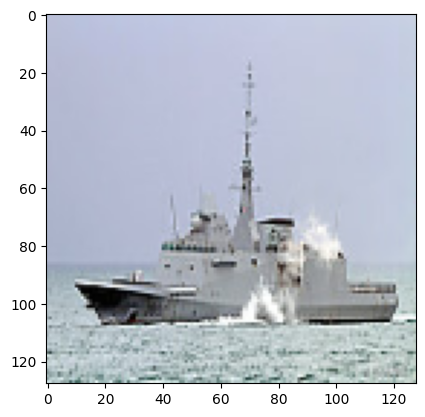

In [35]:
img_data = img[5].numpy()
plt.imshow(img_data/255)
plt.show()

In [33]:
img[1].numpy()

array([[[135.32031 , 163.32031 , 202.32031 ],
        [136.      , 164.      , 203.      ],
        [137.60156 , 165.60156 , 204.60156 ],
        ...,
        [158.      , 173.      , 203.20312 ],
        [157.72656 , 174.6875  , 204.80469 ],
        [149.64062 , 167.67969 , 200.67969 ]],

       [[137.78018 , 165.78018 , 204.78018 ],
        [137.83594 , 165.83594 , 204.83594 ],
        [139.4375  , 167.4375  , 206.4375  ],
        ...,
        [153.96237 , 168.96237 , 199.1655  ],
        [151.40836 , 168.47687 , 198.5582  ],
        [147.21661 , 166.13779 , 198.21982 ]],

       [[140.58984 , 168.58984 , 205.86328 ],
        [141.4194  , 169.4194  , 206.69284 ],
        [142.1914  , 170.1914  , 207.46484 ],
        ...,
        [152.73828 , 169.46484 , 199.49261 ],
        [150.9112  , 167.98932 , 198.      ],
        [148.72656 , 167.72656 , 198.      ]],

       ...,

       [[179.04034 , 159.58105 , 129.44434 ],
        [143.65723 , 123.160095,  95.90619 ],
        [144.08145 , 1

### Podział na zbiór

In [38]:
img_data_tr, img_data_val = keras.utils.image_dataset_from_directory(
    "dane",
    label_mode='categorical',
    batch_size=batch_size,
    image_size=image_size,
    seed=123,
    validation_split=0.2,
    subset='both'
)

Found 6252 files belonging to 5 classes.
Using 5002 files for training.
Using 1250 files for validation.


In [39]:
5002 // batch_size

156

In [40]:
num_classes = len(data_dict.values())
num_classes

5

In [41]:
input_shape = (128, 128, 3)

In [42]:
128 * 128 * 3

49152

In [44]:
img[0].numpy().flatten() # 128 * 128

array([228.     , 228.     , 228.     , ..., 205.51562, 207.51562,
       205.875  ], dtype=float32)

In [45]:
siec = [  # tutaj będzie architerktura modelu
        #  wejście
          keras.layers.Input(shape=input_shape, batch_size=batch_size),
        #  wyjście
          keras.layers.Flatten(),
          keras.layers.Dense(num_classes, activation='softmax')
]
model = keras.Sequential(siec)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (32, 49152)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 5)                     │         245,765 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245,765 (960.02 KB)

 Trainable params: 245,765 (960.02 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
49152 * 5 + 5

245765

In [ ]:
model.fit(img_data_tr, epochs=400, validation_data=img_data_val)

## Model rozbudowany o dodatkowe operacja na danych

In [49]:
siec = [  # tutaj będzie architerktura modelu
        #  wejście
          keras.layers.Input(shape=input_shape, batch_size=batch_size),
          keras.layers.Rescaling(1./255),
          keras.layers.Dropout(0.2),  # powstrzymuje sieć przed przeuczeniem
        #  wyjście
          keras.layers.Flatten(),
          keras.layers.Dense(num_classes, activation='softmax')
]
model = keras.Sequential(siec)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (32, 128, 128, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (32, 128, 128, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (32, 49152)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 5)                     │         245,765 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245,765 (960.02 KB)

 Trainable params: 245,765 (960.02 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.fit(img_data_tr, epochs=50, validation_data=img_data_val)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.2647 - loss: 10.5610 - val_accuracy: 0.2880 - val_loss: 4.3349
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.3201 - loss: 3.3048 - val_accuracy: 0.3296 - val_loss: 4.7448
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.3438 - loss: 3.1852 - val_accuracy: 0.3792 - val_loss: 2.4488
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.3935 - loss: 2.3068 - val_accuracy: 0.2104 - val_loss: 7.7355
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.3716 - loss: 4.2882 - val_accuracy: 0.2768 - val_loss: 5.2551
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.3937 - loss: 3.0377 - val_accuracy: 0.2272 - val_loss: 5.5893
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.3933 - loss: 3.1501 - val_accuracy: 0.3456 - val_loss: 3.6893
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.4218 - loss: 2.4242 - 

In [ ]:
5*5*256

6400

In [ ]:
siec = [  # tutaj będzie architerktura modelu
        #  wejście
          keras.layers.Input(shape=input_shape, batch_size=batch_size),
          keras.layers.Rescaling(1./255),
        #  konwolucje i maxpooling
          keras.layers.Conv2D(32, (3, 3), activation='relu'),
          keras.layers.MaxPooling2D((2, 2)),
          keras.layers.Conv2D(64, (3, 3), activation='relu'),
          keras.layers.MaxPooling2D((2, 2)),
        #  wyjście
          keras.layers.Flatten(),
          keras.layers.Dropout(0.4),  # powstrzymuje sieć przed przeuczeniem
          keras.layers.Dropout(0.4),  # powstrzymuje sieć przed przeuczeniem
          keras.layers.Dense(num_classes, activation='softmax')
]
model = keras.Sequential(siec)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (32, 128, 128, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 126, 126, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 63, 63, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 61, 61, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (32, 57600)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (32, 57600)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (32, 57600)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (32, 5)                     │         288,005 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 307,397 (1.17 MB)

 Trainable params: 307,397 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(img_data_tr, epochs=50, validation_data=img_data_val)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.3667 - loss: 1.5423 - val_accuracy: 0.5224 - val_loss: 1.1822
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5513 - loss: 1.1235 - val_accuracy: 0.6096 - val_loss: 1.0515
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6257 - loss: 0.9842 - val_accuracy: 0.6232 - val_loss: 0.9621
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6607 - loss: 0.8792 - val_accuracy: 0.6232 - val_loss: 0.9533
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6862 - loss: 0.8061 - val_accuracy: 0.6264 - val_loss: 0.9543
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7284 - loss: 0.7179 - val_accuracy: 0.6840 - val_loss: 0.8377
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7538 - loss: 0.6329 - val_accuracy: 0.6912 - val_loss: 0.8432
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7967 - loss: 0.5287 - val_accuracy: 

In [55]:
! pip install keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 31.7 MB/s eta 0:00:00


In [57]:
import keras_cv

In [58]:
backbone = keras_cv.models.EfficientNetV2Backbone.from_preset('efficientnetv2_b0_imagenet')

100%|██████████| 1.79k/1.79k [00:00<00:00, 2.29MB/s]


100%|██████████| 23.1M/23.1M [00:00<00:00, 37.4MB/s]


In [59]:
model = keras_cv.models.ImageClassifier(
    backbone=backbone,
    num_classes=num_classes,
    activation='softmax'
    )

In [60]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [61]:
model.summary()

Model: "image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficient_net_v2b0_backbone          │ (None, None, None, 1280)    │       5,919,312 │
│ (EfficientNetV2Backbone)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ avg_pool (GlobalAveragePooling2D)    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,925,717 (22.60 MB)

 Trainable params: 5,865,109 (22.37 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [62]:
model.fit(img_data_tr, epochs=50, validation_data=img_data_val)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 506s 3s/step - accuracy: 0.7071 - loss: 0.7529 - val_accuracy: 0.8920 - val_loss: 0.2700
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.9142 - loss: 0.2356 - val_accuracy: 0.9016 - val_loss: 0.2655
Epoch 3/50
 93/157 ━━━━━━━━━━━━━━━━━━━━ 2:46 3s/step - accuracy: 0.9503 - loss: 0.1420

KeyboardInterrupt: 

# Testowanie modelu

In [63]:
os.makedirs('test/military', exist_ok=True)# tworzy katalog test i podkatalog military , trzeba wkleic zdjecia z katalogu military w dzien 11 google drive


ladowanie do zmiennej test_images


In [4]:
test_images = keras.utils.image_dataset_from_directory(
    "test/military",
    color_mode='rgb',
    labels=None,
    image_size=image_size,
    seed=123)

NameError: name 'keras' is not defined

Predykcja

In [67]:
test_pred = model.predict(test_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [68]:
test_pred.argmax(axis=1)

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
for images in test_images.take(1):
    image = images[2]
    plt.imshow(image/255)
    plt.show()


NameError: name 'test_images' is not defined

# Testowanie modelu 2


In [ ]:
os.makedirs('test/military', exist_ok=True)

In [ ]:
test_images = keras.utils.image_dataset_from_directory(
    "test/military",
    color_mode='rgb',
    labels=None,
    image_size=image_size,
    shuffle=False,  # dzieki temu obrazki za każdym razem będą sie pojawiać w tej samej kolejności
    seed=123)

Found 20 files.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


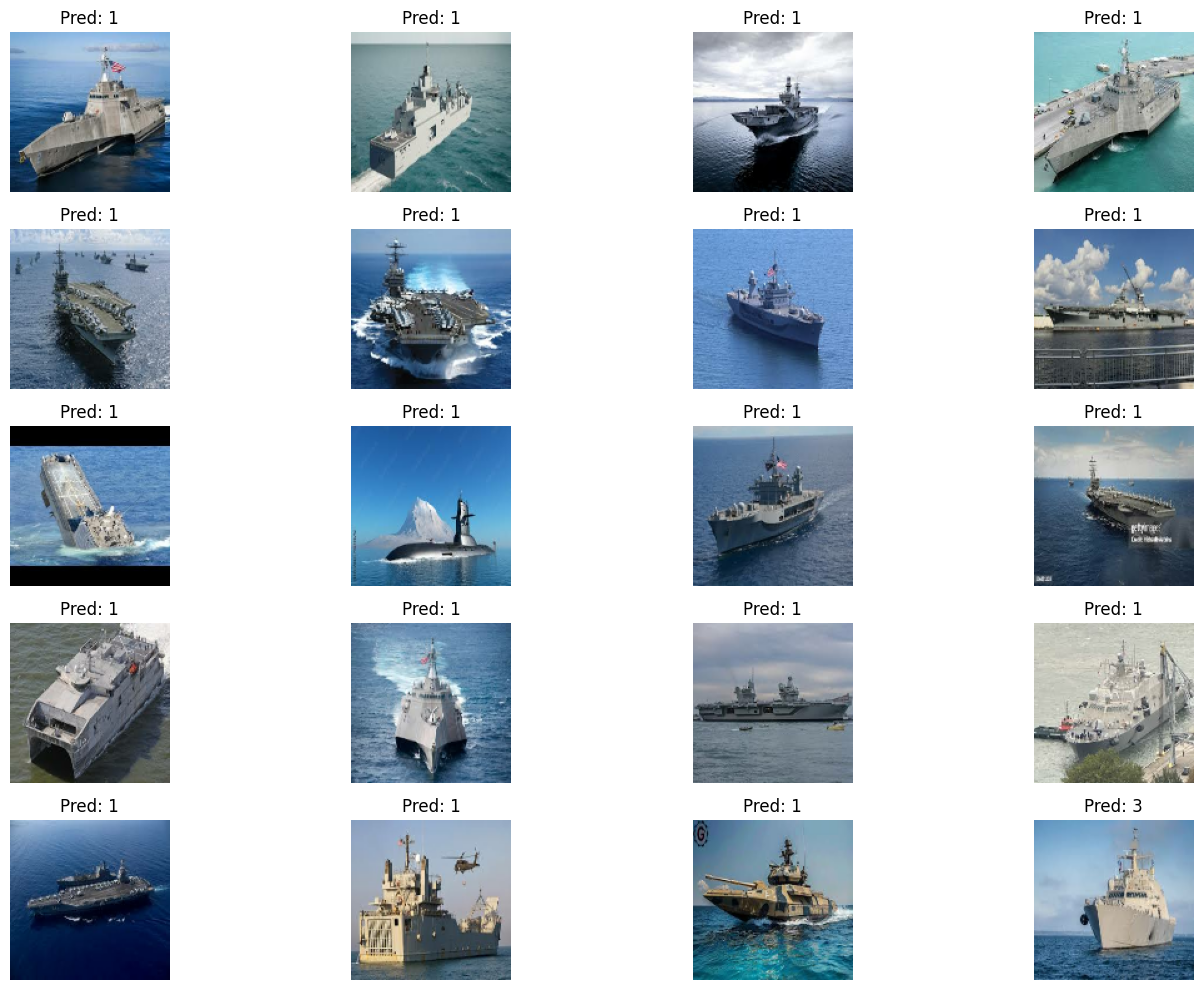

In [ ]:
image_list = []
for img_batch in test_images:
    image_list.extend(img_batch.numpy())

predictions = model.predict(test_images)


fig, axes = plt.subplots(5, 4, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
        image = image_list[i]
        prediction = predictions[i]

        ax.imshow(image/255)
        ax.set_title(f"Pred: {prediction.argmax()}")
        ax.axis("off")

plt.tight_layout()
plt.show()